In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
file_path = r'C:\Users\sharif\Desktop\6.9-Final_AllReactive.xlsx'
df = pd.read_excel(file_path)
df.head()

,"STREAMS(""ETHANOL"").T","STREAMS(""P-ACID"").T","STREAMS(""S15"").T","STREAMS(""C1-INPUT"").T","STREAMS(""S26"").T","STREAMS(""S28"").T","STREAMS(""ETHANOL"").P","STREAMS(""P-ACID"").P","STREAMS(""S15"").P","STREAMS(""C1-INPUT"").P",...,"BLOCKS(""C1"").Stage(29).T","BLOCKS(""C1"").Stage(30).T","BLOCKS(""C1"").Stage(31).T","BLOCKS(""C1"").Stage(32).T","BLOCKS(""C1"").Stage(33).T","STREAMS(""D1"").Zmn(""ETHYL-01"")","STREAMS(""S29"").Zmn(""ETHYL-01"")","STREAMS(""S8"").Zmn(""ETHYL-01"")","STREAMS(""S29"").F","STREAMS(""D1"").F"
0,25.0,25.0,146.692,139.972,25.4830,25.3346,1.01325,1.01325,1.20551,1.20551,...,141.881,142.038,142.194,142.349,142.584,0.933737,0.999927,0.740045,49.0159,287.386
1,25.0,25.0,146.693,139.972,25.4839,25.3356,1.01325,1.01325,1.20552,1.20552,...,141.883,142.039,142.195,142.351,142.585,0.933735,0.999927,0.740045,49.0159,287.387
2,25.0,25.0,146.693,139.972,25.4844,25.3361,1.01325,1.01325,1.20552,1.20552,...,141.884,142.040,142.196,142.352,142.586,0.933733,0.999927,0.740045,49.0159,287.387
3,25.0,25.0,146.693,139.972,25.4846,25.3363,1.01325,1.01325,1.20552,1.20552,...,141.884,142.041,142.197,142.352,142.586,0.933731,0.999927,0.740045,49.0160,287.387
4,25.0,25.0,146.693,139.972,25.4848,25.3365,1.01325,1.01325,1.20553,1.20553,...,141.885,142.041,142.197,142.352,142.586,0.933730,0.999927,0.740045,49.0160,287.387


In [3]:
df.describe

<bound method NDFrame.describe of        STREAMS("ETHANOL").T  STREAMS("P-ACID").T  STREAMS("S15").T  \
0                      25.0                 25.0           146.692   
1                      25.0                 25.0           146.693   
2                      25.0                 25.0           146.693   
3                      25.0                 25.0           146.693   
4                      25.0                 25.0           146.693   
...                     ...                  ...               ...   
11181                  25.0                 25.0           146.736   
11182                  25.0                 25.0           146.736   
11183                  25.0                 25.0           146.736   
11184                  25.0                 25.0           146.736   
11185                  25.0                 25.0           146.736   

       STREAMS("C1-INPUT").T  STREAMS("S26").T  STREAMS("S28").T  \
0                    139.972           25.4830           

# PreProcessing

In [4]:
x = df.iloc[:, :-5].values
y = df.iloc[:, -5:].values 

In [5]:
x

array([[ 25.   ,  25.   , 146.692, ..., 142.194, 142.349, 142.584],
       [ 25.   ,  25.   , 146.693, ..., 142.195, 142.351, 142.585],
       [ 25.   ,  25.   , 146.693, ..., 142.196, 142.352, 142.586],
       ...,
       [ 25.   ,  25.   , 146.736, ..., 142.237, 142.392, 142.625],
       [ 25.   ,  25.   , 146.736, ..., 142.237, 142.392, 142.625],
       [ 25.   ,  25.   , 146.736, ..., 142.237, 142.392, 142.625]],
      shape=(11186, 83))

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train = scaler_x.fit_transform(x_train)
x_test = scaler_x.transform(x_test)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

In [8]:
x_train = np.expand_dims(x_train, axis=1)
x_test = np.expand_dims(x_test, axis=1)

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_tft_model(input_shape, output_dim, d_model=128, dff=256, num_heads=8, dropout_rate=0.2):
    """
    ساخت یک مدل ساده‌شده‌ی Transformer برای پیش‌بینی چندمتغیره
    """
    # ورودی
    inputs = layers.Input(shape=input_shape)  # (batch_size, time_steps, features)

    # لایه فشرده‌سازی اولیه
    x = layers.Dense(d_model)(inputs)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # بلاک Attention
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout_rate)(attn_output)
    x = layers.Add()([x, attn_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Feed-forward network
    ffn_output = layers.Dense(dff, activation='relu')(x)
    ffn_output = layers.Dense(d_model)(ffn_output)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    x = layers.Add()([x, ffn_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # خلاصه‌سازی زمانی
    x = layers.GlobalAveragePooling1D()(x)

    # خروجی با تعداد تارگت‌ها
    outputs = layers.Dense(output_dim)(x)

    # تعریف مدل
    model = models.Model(inputs=inputs, outputs=outputs)
    return model


# آماده‌سازی پارامترها از داده‌های آموزشی
input_shape = x_train.shape[1:]    # (time_steps, features)
output_dim = y_train.shape[1]      # تعداد تارگت‌ها

# ساخت مدل
tft_model = build_tft_model(input_shape, output_dim)

# کامپایل مدل
tft_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

# نمایش خلاصه ساختار مدل
tft_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1, 83)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 128)    │     10,752 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 128)    │        256 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 128)    │    527,488 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1, 128)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 128)    │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 256)    │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 128)    │     32,896 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1, 128)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 128)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 128)    │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        645 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 605,573 (2.31 MB)

 Trainable params: 605,573 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = tft_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=200,
    batch_size=32,
    verbose=1
)

Epoch 1/200
280/280 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - loss: 0.6263 - mae: 0.5106 - val_loss: 0.1919 - val_mae: 0.1966
Epoch 2/200
280/280 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 0.2718 - mae: 0.3054 - val_loss: 0.1436 - val_mae: 0.1413
Epoch 3/200
280/280 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - loss: 0.1713 - mae: 0.2482 - val_loss: 0.1026 - val_mae: 0.1437
Epoch 4/200
280/280 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - loss: 0.1345 - mae: 0.2306 - val_loss: 0.0572 - val_mae: 0.1122
Epoch 5/200
280/280 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - loss: 0.0967 - mae: 0.2060 - val_loss: 0.0368 - val_mae: 0.1031
Epoch 6/200
280/280 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 0.0696 - mae: 0.1841 - val_loss: 0.0282 - val_mae: 0.0971
Epoch 7/200
280/280 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.0574 - mae: 0.1698 - val_loss: 0.0219 - val_mae: 0.0875
Epoch 8/200
280/280 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.0488 - mae: 0.1568 - val_loss: 0.0197 - val_mae: 0.0801
Epoch 9/200
280/280 ━━━━━━━━━━━━

In [11]:
test_loss, test_mae = tft_model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss}")
print(f"Test MAE: {test_mae}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0083 - mae: 0.0231
Test Loss: 0.006249073427170515
Test MAE: 0.023306725546717644


In [12]:
y_pred = tft_model.predict(x_test)

70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [13]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

mse = mean_squared_error(y_test , y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE:{mse}")
print(f"MAE:{mae}")
print(f"R2 Score:{r2}")

MSE:0.006249072425137868
MAE:0.02330672598258322
R2 Score:0.9943008087535624


In [14]:
for i in range(y_test.shape[1]):
    mse = mean_squared_error(y_test[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    print(f"Target {i+1}: MSE={mse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

Target 1: MSE=0.0009, MAE=0.0201, R2=0.9991
Target 2: MSE=0.0281, MAE=0.0439, R2=0.9747
Target 3: MSE=0.0006, MAE=0.0157, R2=0.9994
Target 4: MSE=0.0010, MAE=0.0199, R2=0.9990
Target 5: MSE=0.0007, MAE=0.0169, R2=0.9993


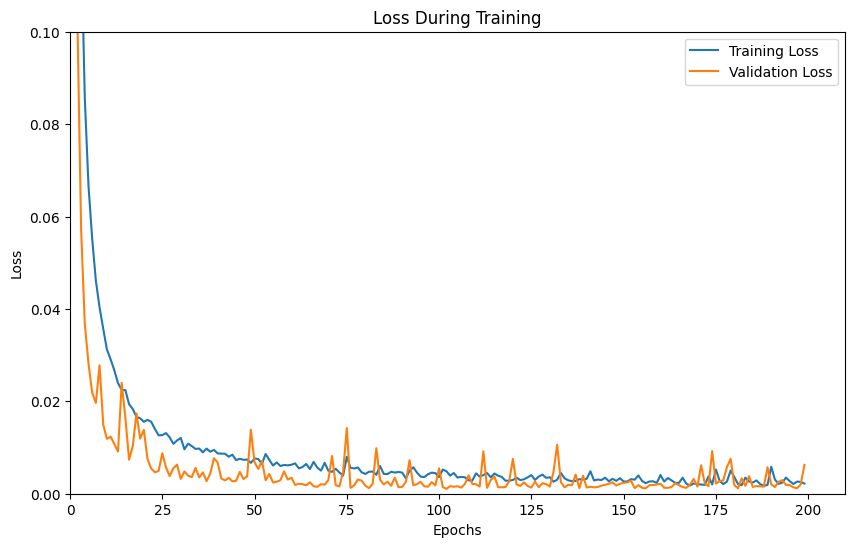

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss During Training')
plt.legend()
plt.xlim(0,210)
plt.ylim(0,0.1)
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

test_loss, test_mae = tft_model.evaluate(x_test, y_test, verbose=1)

print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test Mean Absolute Error (MAE): {test_mae:.4f}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0083 - mae: 0.0231
Test Loss (MSE): 0.0062
Test Mean Absolute Error (MAE): 0.0233


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = tft_model.predict(x_test)

y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Mean Squared Error (MSE): 0.0006
Mean Absolute Error (MAE): 0.0083
R^2 Score: 0.9921


In [18]:
import pandas as pd

# اسامی دقیق تارگت‌ها
labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']

# ساخت دیکشنری برای DataFrame
data = {}
for i, label in enumerate(labels):
    data[f'Actual {label}'] = y_test_inv[:, i]
    data[f'Predicted {label}'] = y_pred_inv[:, i]

# تبدیل به DataFrame
results = pd.DataFrame(data)

# نمایش 20 نمونه اول
print(results.head(20))

    Actual Target1  Predicted Target1  Actual Target2  Predicted Target2  \
0         0.934459           0.934439        0.999927           0.999927   
1         0.932505           0.932477        0.999927           0.999927   
2         0.934781           0.934817        0.999927           0.999927   
3         0.935380           0.935386        0.999927           0.999927   
4         0.933617           0.933599        0.999927           0.999927   
5         0.934550           0.934531        0.999927           0.999927   
6         0.932988           0.932977        0.999927           0.999927   
7         0.933740           0.933730        0.999927           0.999927   
8         0.934661           0.934637        0.999927           0.999927   
9         0.934776           0.934750        0.999927           0.999927   
10        0.934512           0.934503        0.999927           0.999927   
11        0.934099           0.934105        0.999927           0.999927   
12        0.

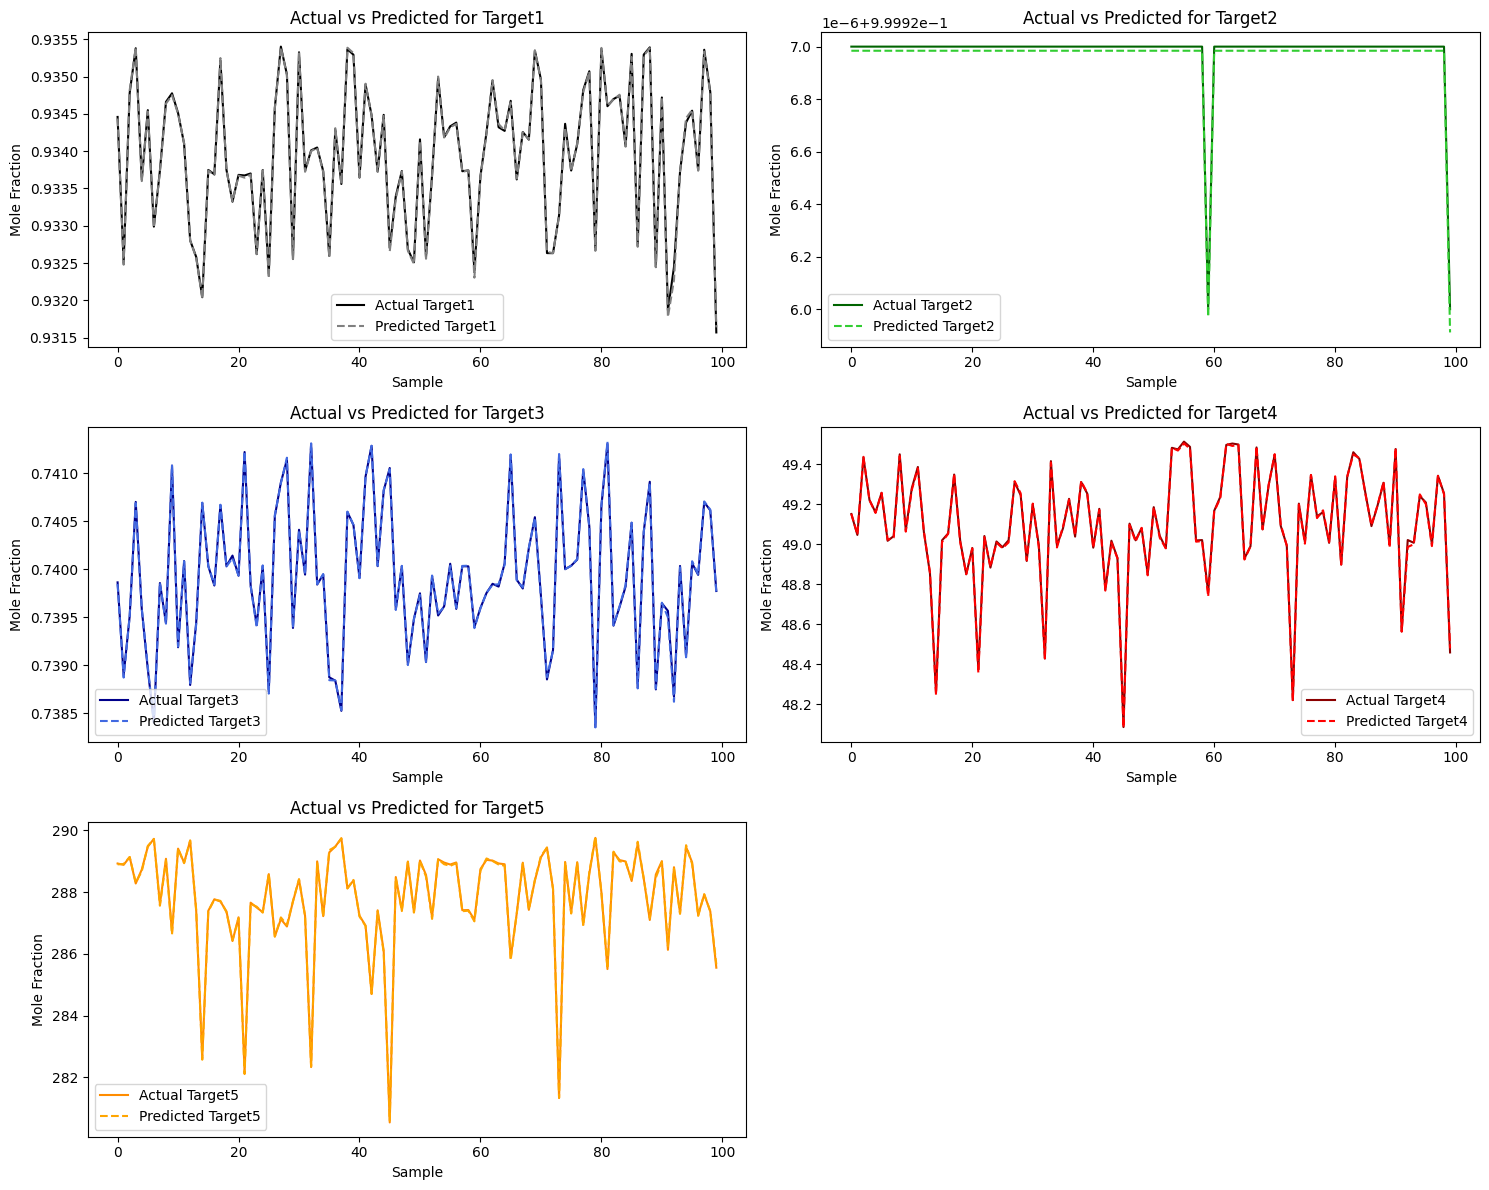

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# لیست اسامی تارگت‌ها
targets = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']

# ساخت DataFrame با استفاده از تارگت‌ها
data = {}
for i, label in enumerate(targets):
    data[f'Actual {label}'] = y_test_inv[:, i]
    data[f'Predicted {label}'] = y_pred_inv[:, i]

results = pd.DataFrame(data)

# انتخاب 100 نمونه اول
subset = results.iloc[:100]

# رنگ‌ها برای نمودارها
actual_colors = ['black', 'darkgreen', 'darkblue', 'darkred', 'darkorange']
predicted_colors = ['gray', 'limegreen', 'royalblue', 'red', 'orange']

# رسم نمودار برای هر تارگت
plt.figure(figsize=(15, 12))
for i, target in enumerate(targets):
    plt.subplot(3, 2, i + 1)
    if f'Actual {target}' in subset.columns and f'Predicted {target}' in subset.columns:
        plt.plot(subset[f'Actual {target}'], label=f'Actual {target}', color=actual_colors[i])
        plt.plot(subset[f'Predicted {target}'], linestyle='--', label=f'Predicted {target}', color=predicted_colors[i])
        plt.xlabel('Sample')
        plt.ylabel('Mole Fraction')
        plt.title(f'Actual vs Predicted for {target}')
        plt.legend()
    else:
        plt.text(0.5, 0.5, f'{target} not found', ha='center')
plt.tight_layout()
plt.show()

In [20]:
def percentage_within_tolerance(y_true, y_pred, tolerance):
    diff = np.abs(y_true - y_pred)
    within_tol = np.sum(diff <= tolerance)
    return (within_tol / len(y_true)) * 100

In [21]:
labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']  # به ترتیب: 3 تا غلظت، 2 تا دبی

# تولرانس‌های جداگانه برای هر خروجی
tolerances_per_output = {
    'Target1': [0.001, 0.0001, 0.00005],  # غلظت
    'Target2': [0.001, 0.0001, 0.00005],  # غلظت
    'Target3': [0.001, 0.0001, 0.00005],  # غلظت
    'Target4': [0.02, 0.05, 0.1],             # دبی
    'Target5': [0.02, 0.05, 0.1]              # دبی
}
all_results = {label: [] for label in labels}

In [22]:
# بررسی دقت بر اساس تولرانس‌های اختصاصی هر خروجی
for label_index, label in enumerate(labels):
    print(f"\n--- Accuracy for {label} ---")
    for tol in tolerances_per_output[label]:
        acc = percentage_within_tolerance(y_test_inv[:, label_index], y_pred_inv[:, label_index], tolerance=tol)
        all_results[label].append(acc)
        print(f"Tolerance ±{tol}: {acc:.2f}%")


--- Accuracy for Target1 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 99.46%
Tolerance ±5e-05: 93.74%

--- Accuracy for Target2 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 100.00%
Tolerance ±5e-05: 100.00%

--- Accuracy for Target3 ---
Tolerance ±0.001: 100.00%
Tolerance ±0.0001: 99.82%
Tolerance ±5e-05: 98.79%

--- Accuracy for Target4 ---
Tolerance ±0.02: 98.08%
Tolerance ±0.05: 99.78%
Tolerance ±0.1: 99.96%

--- Accuracy for Target5 ---
Tolerance ±0.02: 33.15%
Tolerance ±0.05: 77.88%
Tolerance ±0.1: 97.41%


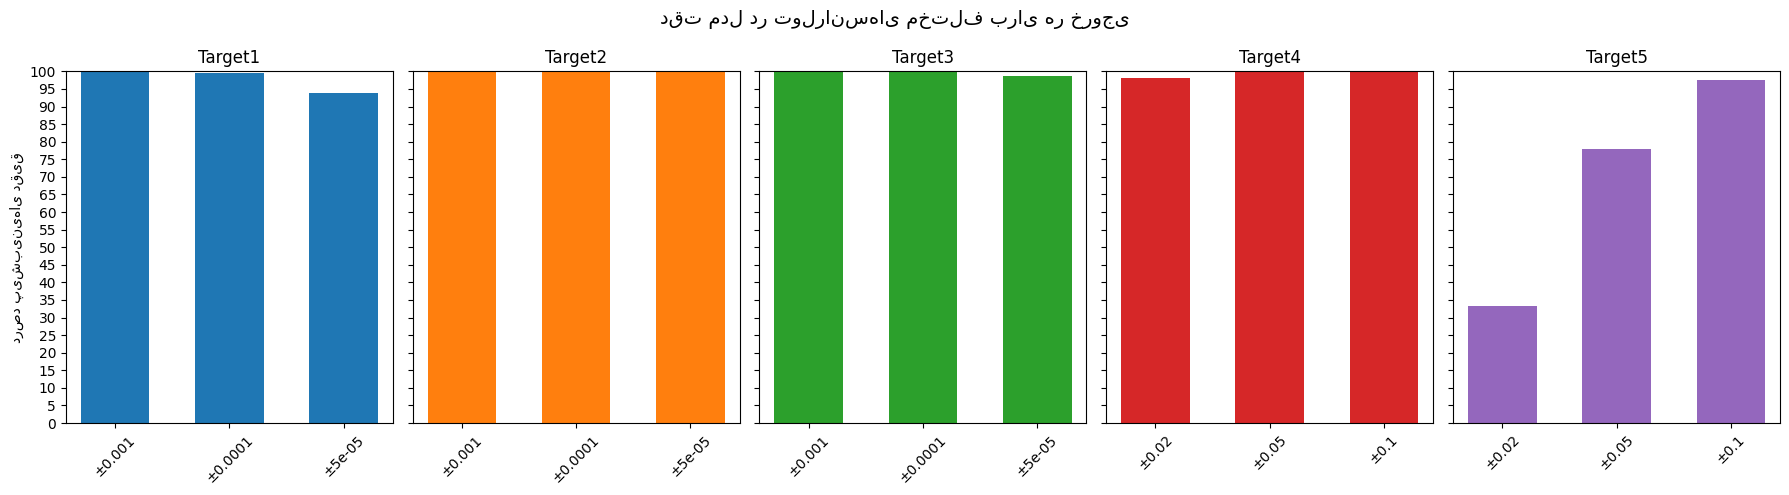

In [23]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Target1', 'Target2', 'Target3', 'Target4', 'Target5']

# فرض: all_results دیکشنری با مقادیر لیستی از دقت‌ها
# مثل {'Target1': [...], 'Target2': [...], ...}

fig, axs = plt.subplots(1, len(labels), figsize=(18, 5), sharey=True)

for i, label in enumerate(labels):
    accs = all_results[label]
    tols = tolerances_per_output[label]
    
    x = np.arange(len(tols))
    axs[i].bar(x, accs, color=plt.cm.tab10(i), width=0.6)
    axs[i].set_xticks(x)
    axs[i].set_xticklabels([f'±{t}' for t in tols], rotation=45)
    axs[i].set_title(label)
    axs[i].set_ylim(0, 100)
    axs[i].set_yticks(np.arange(0, 101, 5))

axs[0].set_ylabel("درصد پیش‌بینی‌های دقیق")
fig.suptitle("دقت مدل در تولرانس‌های مختلف برای هر خروجی", fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
import shap
import pandas as pd

d:\ArshadProjectVSCode\final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
feature_names = df.drop([
    'STREAMS("D1").Zmn("ETHYL-01")',
    'STREAMS("S29").Zmn("ETHYL-01")',
    'STREAMS("S8").Zmn("ETHYL-01")',
    'STREAMS("S29").F',
    'STREAMS("D1").F'
], axis=1).columns.tolist()

In [26]:
x_sample = x_train[:100]  # شکلی مانند (100, 1, 15)
x_test_sample = x_test[:100]

In [27]:
def model_3d_wrapper(data_2d):
    data_3d = np.expand_dims(data_2d, axis=1)  # (batch, 1, features)
    return tft_model.predict(data_3d)

In [28]:
explainer = shap.Explainer(model_3d_wrapper, x_sample[:, 0, :], feature_names=feature_names)
shap_values = explainer(x_test_sample[:, 0, :])

497/497 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
497/497 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
497/497 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


PermutationExplainer explainer:   1%|          | 1/100 [00:00<?, ?it/s]

494/494 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
494/494 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
494/494 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
260/260 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


PermutationExplainer explainer:   3%|▎         | 3/100 [00:43<13:31,  8.36s/it]

494/494 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
494/494 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
494/494 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


...

PermutationExplainer explainer:  99%|█████████▉| 99/100 [27:57<00:17, 17.39s/it]

500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step
258/258 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


PermutationExplainer explainer: 100%|██████████| 100/100 [28:14<00:00, 17.36s/it]

489/489 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step
489/489 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
489/489 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
257/257 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


PermutationExplainer explainer: 101it [28:32, 17.13s/it]                         



Feature importance for output 1


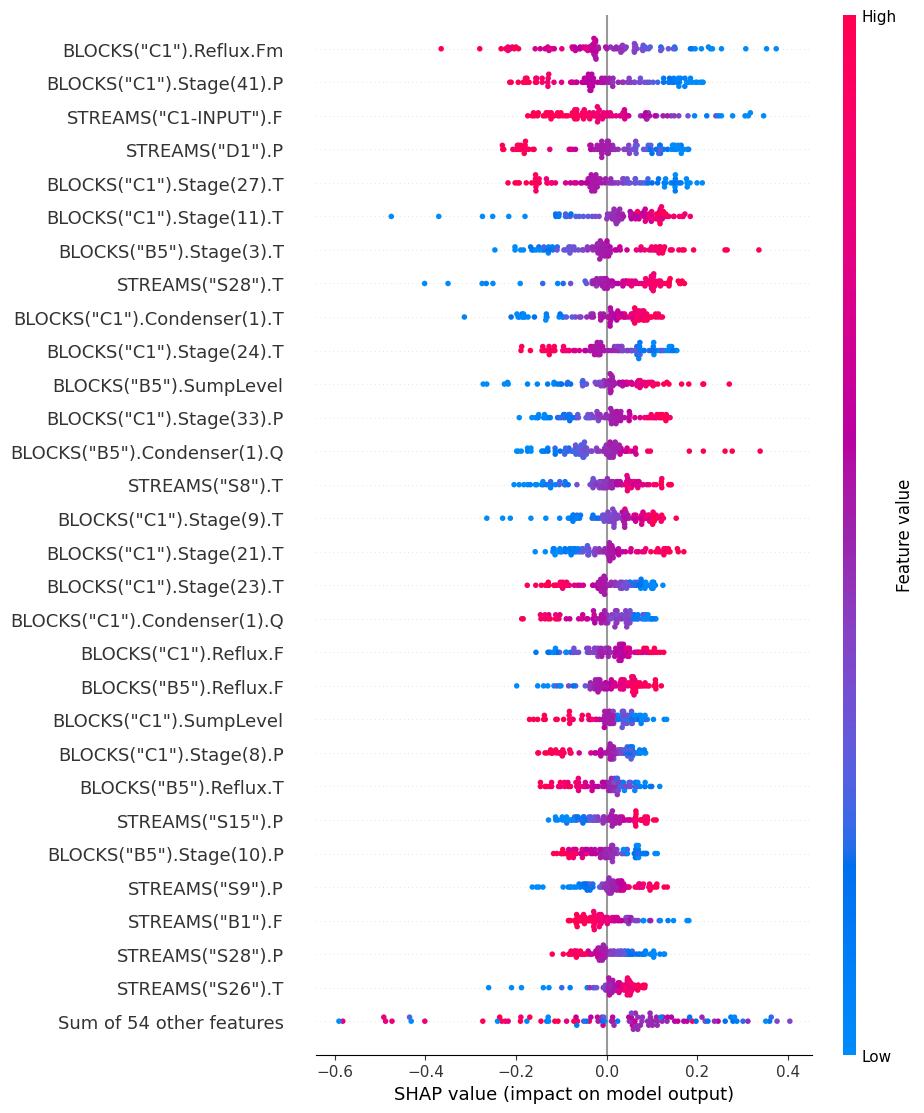


Feature importance for output 2


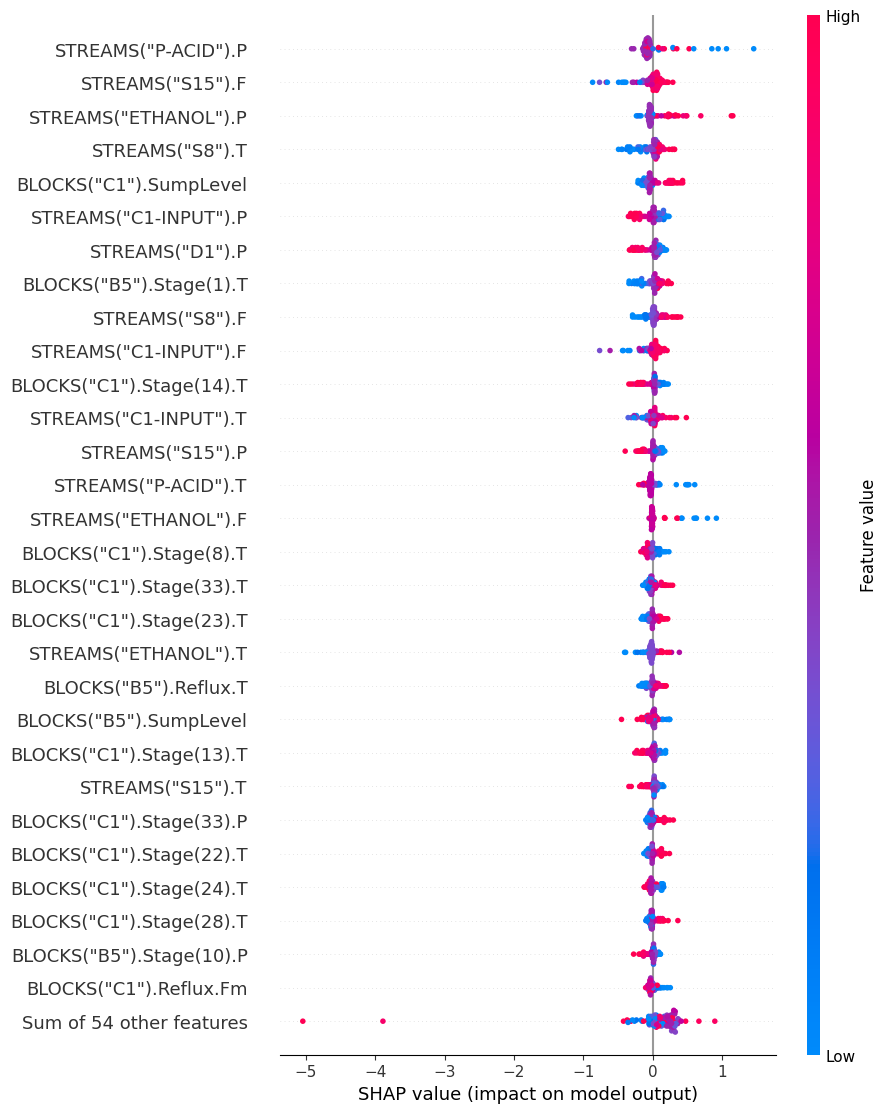


Feature importance for output 3


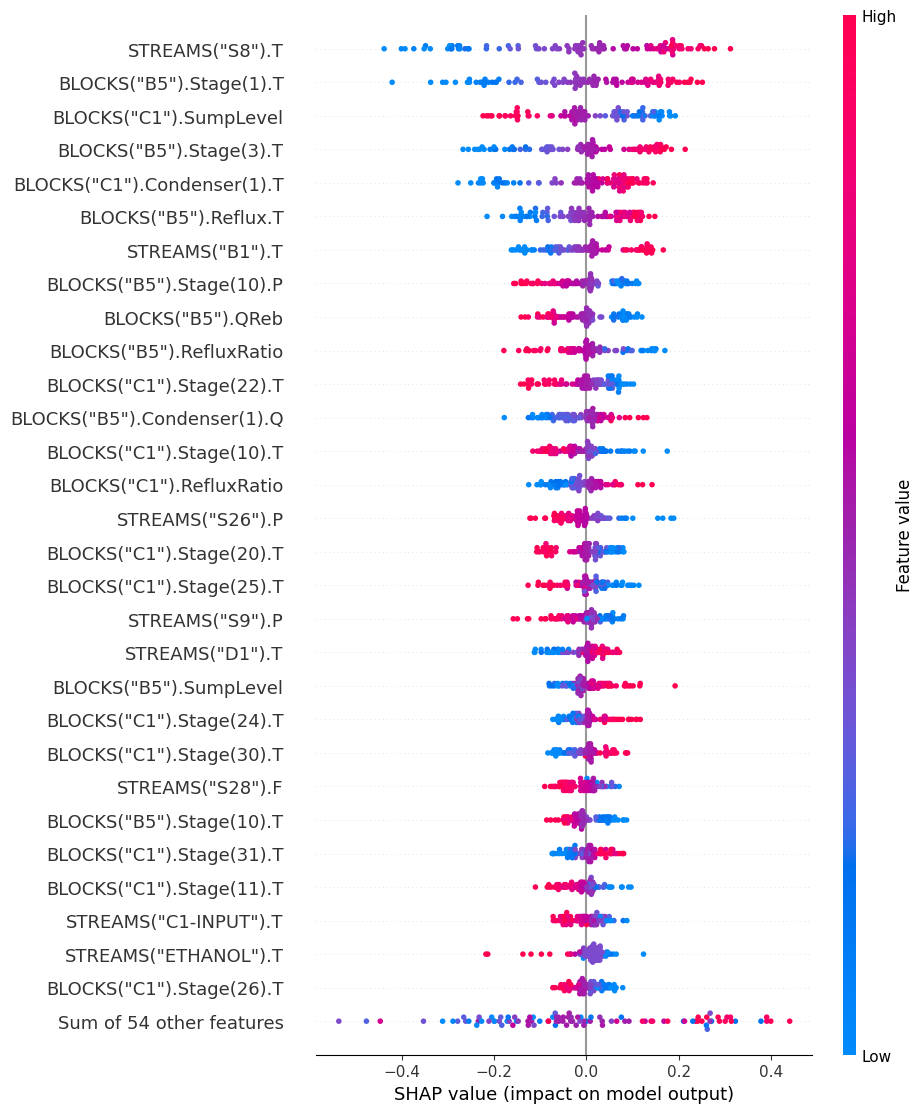


Feature importance for output 4


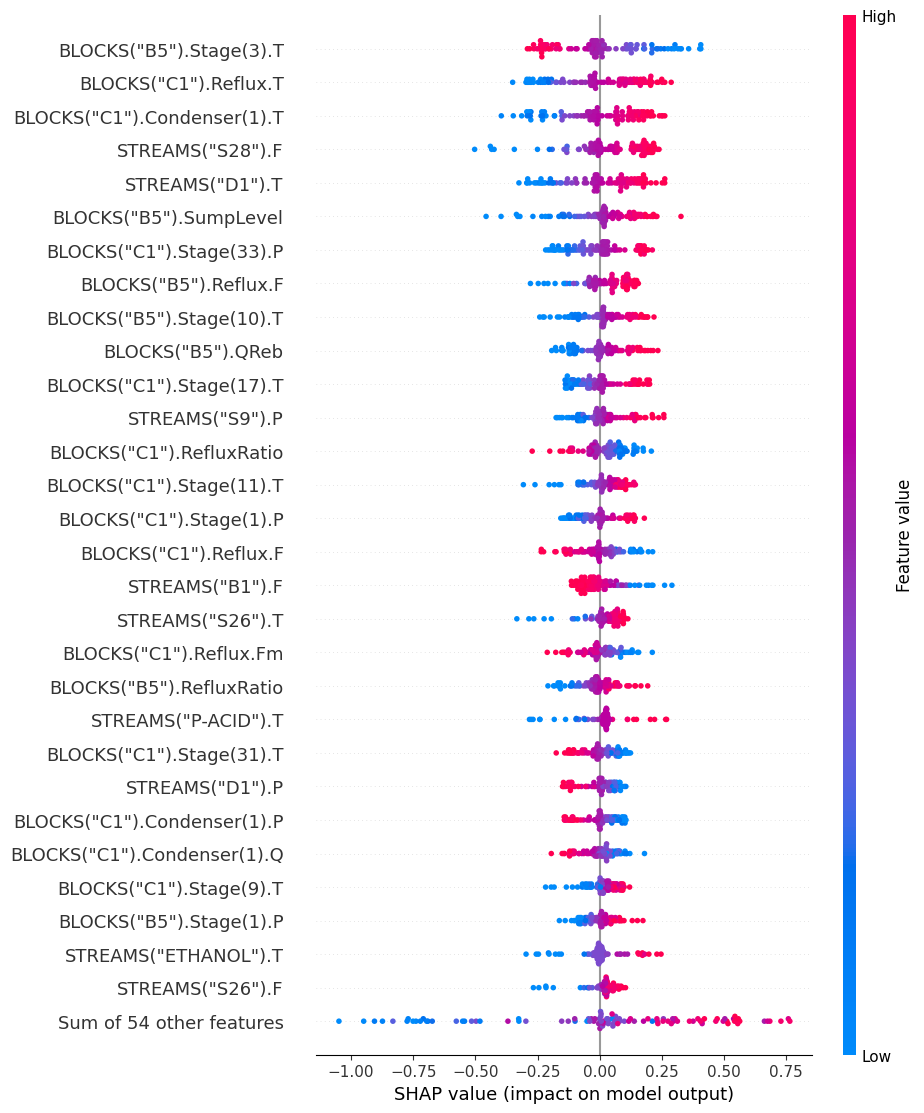


Feature importance for output 5


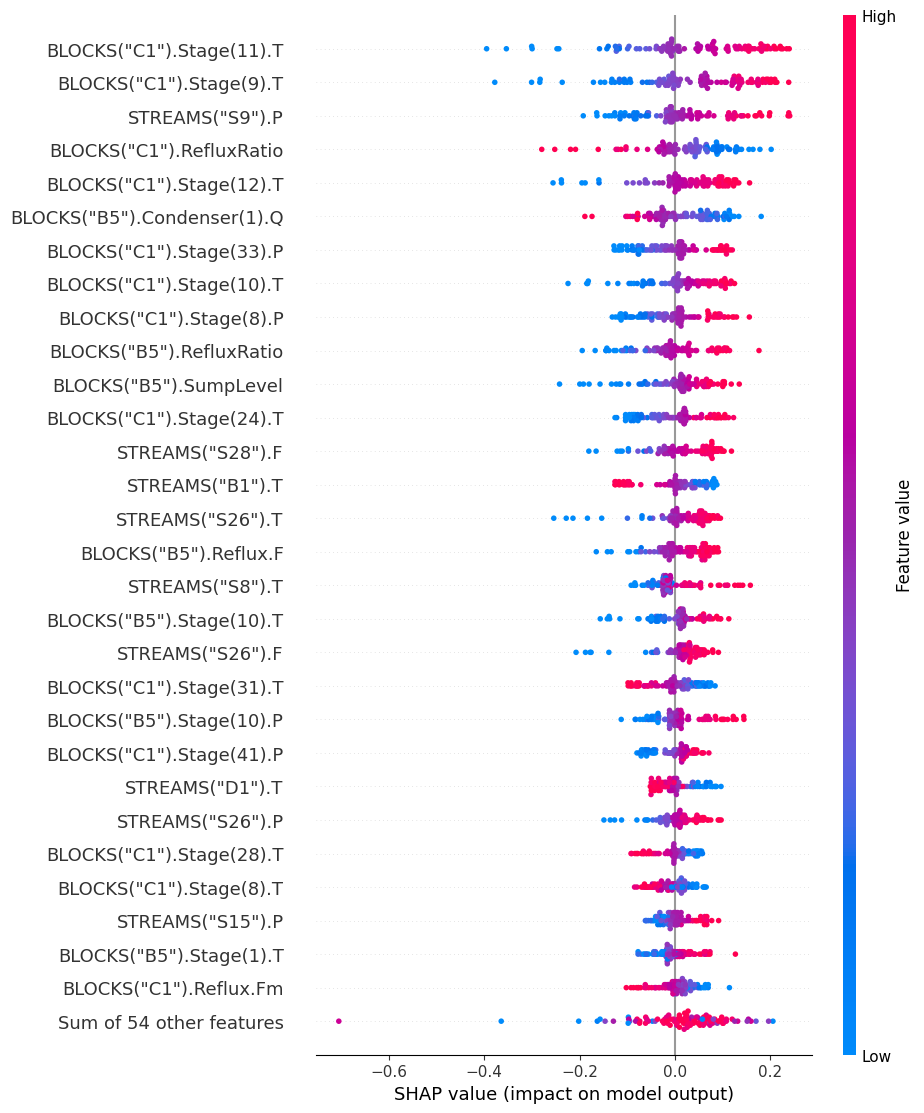

In [29]:
for i in range(y_test.shape[1]):
    print(f"\nFeature importance for output {i+1}")
    shap.plots.beeswarm(shap_values[:, :, i], max_display=30)

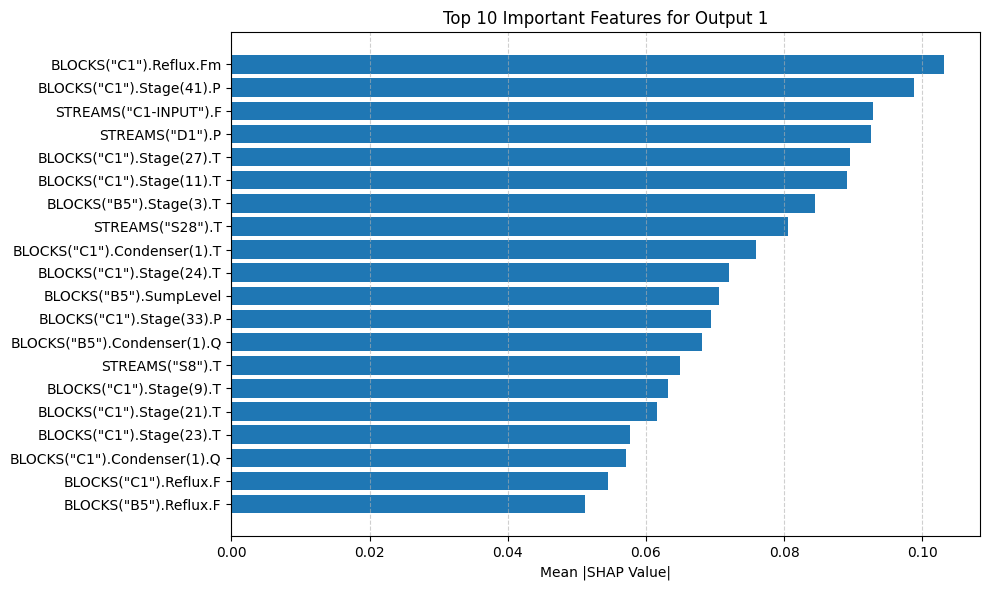

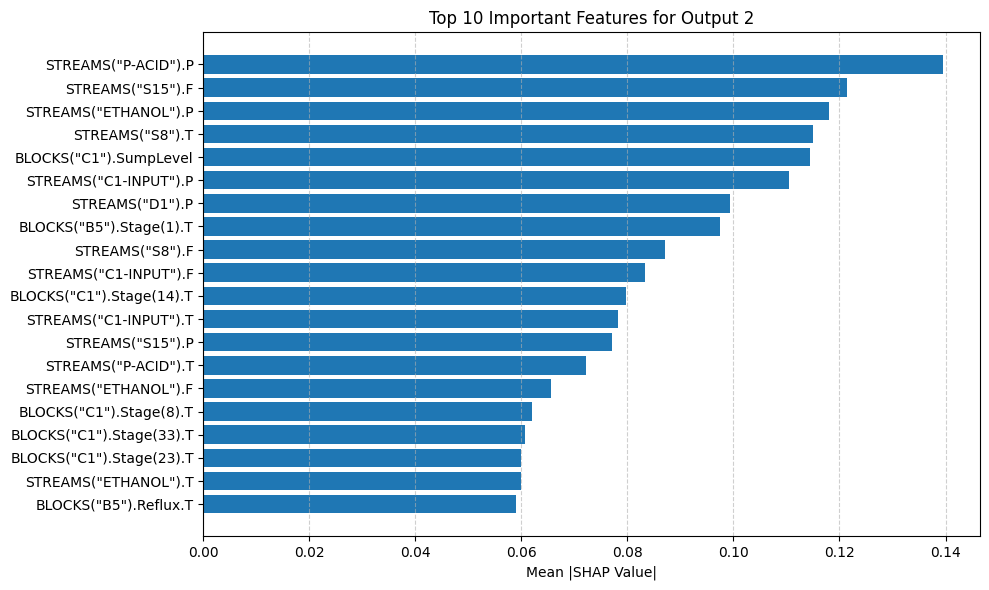

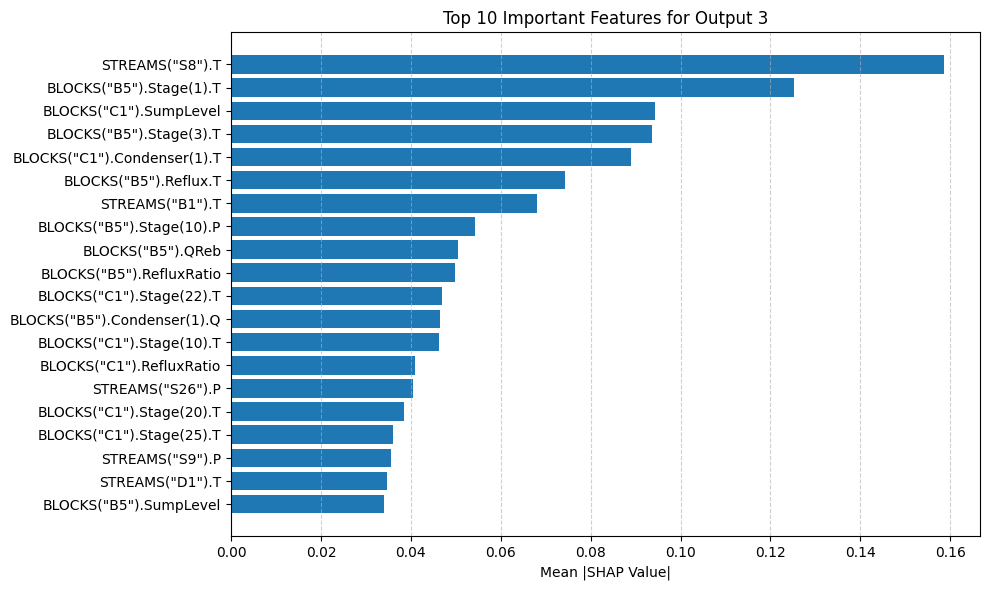

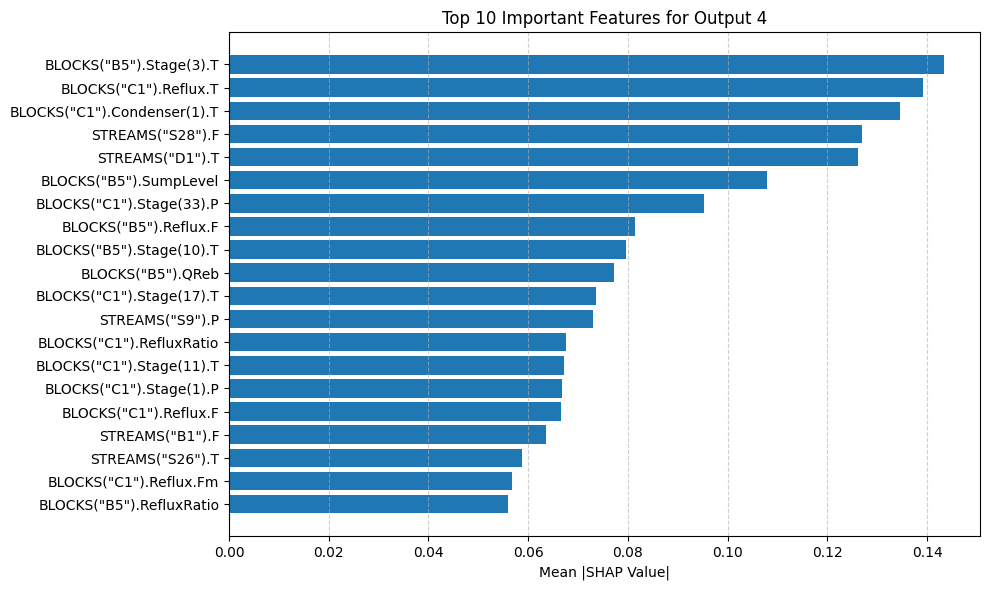

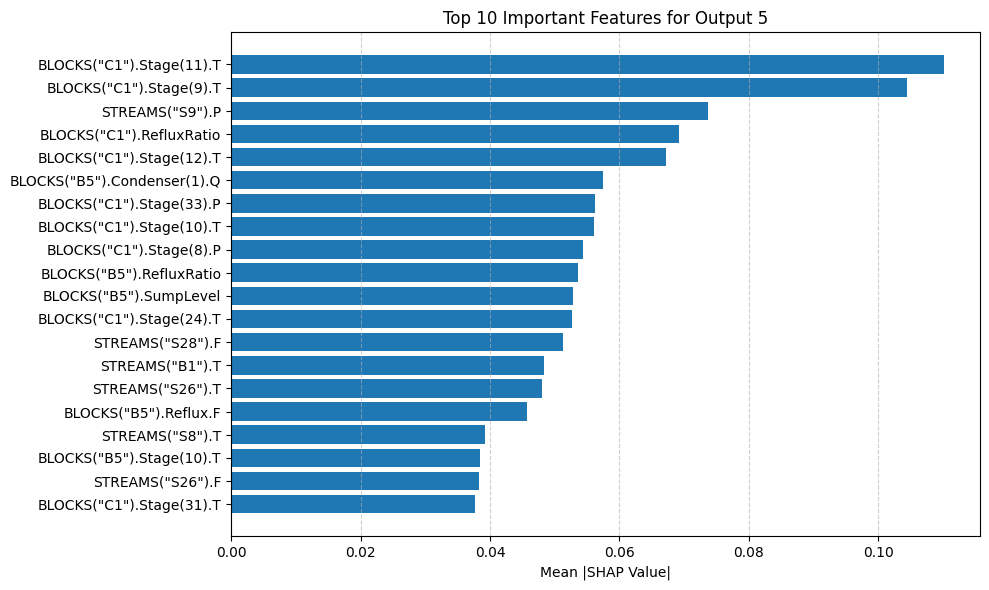

In [30]:
for output_index in range(y_test.shape[1]):
    shap_vals = shap_values[:, :, output_index].values  # shap برای خروجی i‌ام
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)  # میانگین قدر مطلق

    # گرفتن 10 فیچر مهم
    top_indices = np.argsort(mean_abs_shap)[::-1][:20]
    top_features = [feature_names[i] for i in top_indices]
    top_values = mean_abs_shap[top_indices]

    # رسم بارپلات
    plt.figure(figsize=(10, 6))
    plt.barh(top_features[::-1], top_values[::-1])  # وارونه برای نمایش درست
    plt.xlabel("Mean |SHAP Value|")
    plt.title(f"Top 10 Important Features for Output {output_index + 1}")
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()